# VIIRS 数据提取 - 费城照明公平项目

**目标：** 从VIIRS卫星数据中提取费城每个社区的夜间亮度

**输入：** 
- VIIRS HDF5文件（viirs_data文件夹）✓
- 费城Census Block Groups (tl_2020_42_bg文件夹) ✓

**输出：** 
- `philly_lighting_data.shp` - 包含每个社区的VIIRS亮度数据

## Step 1: 安装必要的库

In [20]:
# ============================================================================
# 检查和清理VIIRS数据
# ============================================================================

import re
from collections import defaultdict

print("="*70)
print("VIIRS数据检查报告")
print("="*70)

# 1. 按tile和时间分类所有文件
tile_data = defaultdict(lambda: defaultdict(list))
product_summary = defaultdict(int)

for vfile in viirs_files:
    filename = os.path.basename(vfile)
    
    try:
        # 解析文件名：VNP46A3.A2024001.h10v05.001.2024016052110.h5
        parts = filename.split('.')
        product = parts[0]  # VNP46A2 或 VNP46A3
        date_str = parts[1]  # A2024001
        tile = parts[2]      # h10v05
        
        # 提取年份和日期
        year = int(date_str[1:5])
        doy = int(date_str[5:8])
        date = datetime.strptime(f"{year}-{doy}", "%Y-%j")
        
        # 记录
        tile_data[tile][product].append({
            'file': vfile,
            'filename': filename,
            'date': date,
            'year': year,
            'month': date.strftime('%Y-%m')
        })
        
        product_summary[f"{product}_{tile}"] += 1
        
    except Exception as e:
        print(f"⚠️ 无法解析: {filename}")

# 2. 显示概览
print("\n📊 数据概览:")
print("-"*70)
print(f"总文件数: {len(viirs_files)}")
print(f"\n按产品和Tile分类:")
for key in sorted(product_summary.keys()):
    product, tile = key.split('_')
    region = "费城区域" if tile.startswith('h10v') else "其他区域"
    print(f"  {product} - {tile} ({region}): {product_summary[key]} 个文件")

# 3. 检查费城数据 (h10v04 和 h10v05)
print("\n" + "="*70)
print("📍 费城区域数据详情 (h10v04 和 h10v05)")
print("="*70)

philly_tiles = ['h10v04', 'h10v05']
files_to_keep = []
files_to_delete = []

for tile in philly_tiles:
    if tile not in tile_data:
        print(f"\n⚠️ {tile}: 没有数据")
        continue
    
    print(f"\n{tile}:")
    for product in sorted(tile_data[tile].keys()):
        files = tile_data[tile][product]
        
        # 按年份分组
        by_year = defaultdict(list)
        for f in files:
            by_year[f['year']].append(f)
        
        print(f"\n  {product}:")
        for year in sorted(by_year.keys()):
            year_files = by_year[year]
            months = sorted(set(f['month'] for f in year_files))
            
            # 判断是否保留
            is_target_year = 2022 <= year <= 2024
            is_monthly = product == 'VNP46A3'  # 月度数据
            
            status = "✓ 保留" if (is_target_year and is_monthly) else "✗ 删除"
            
            print(f"    {year}年: {len(year_files)} 个文件, {len(months)} 个月")
            print(f"           月份: {', '.join(months)}")
            print(f"           {status}")
            
            # 记录
            if is_target_year and is_monthly:
                files_to_keep.extend([f['file'] for f in year_files])
            else:
                files_to_delete.extend([f['file'] for f in year_files])

# 4. 检查2022-2024的月度覆盖
print("\n" + "="*70)
print("📅 2022-2024月度覆盖检查")
print("="*70)

# 收集所有应该保留的月份
all_months = defaultdict(int)
for f in files_to_keep:
    filename = os.path.basename(f)
    try:
        parts = filename.split('.')
        date_str = parts[1]
        year = int(date_str[1:5])
        doy = int(date_str[5:8])
        date = datetime.strptime(f"{year}-{doy}", "%Y-%j")
        month_key = date.strftime('%Y-%m')
        all_months[month_key] += 1
    except:
        pass

# 按年份显示
for year in [2022, 2023, 2024]:
    year_months = {k: v for k, v in all_months.items() if k.startswith(str(year))}
    print(f"\n{year}年: {len(year_months)} 个月")
    
    if len(year_months) > 0:
        months_list = sorted(year_months.keys())
        for i in range(0, len(months_list), 6):
            print(f"  {', '.join(months_list[i:i+6])}")
        
        # 检查缺失月份
        expected_months = [f"{year}-{m:02d}" for m in range(1, 13)]
        missing = [m for m in expected_months if m not in year_months]
        if missing:
            print(f"  ⚠️ 缺失月份: {', '.join(missing)}")
    else:
        print(f"  ❌ 没有数据")

# 5. 总结和建议
print("\n" + "="*70)
print("📋 总结和建议")
print("="*70)

print(f"\n文件统计:")
print(f"  总文件数: {len(viirs_files)}")
print(f"  保留 (2022-2024月度): {len(files_to_keep)}")
print(f"  删除 (其他): {len(files_to_delete)}")

# 检查是否能完成任务
total_months = len(all_months)
expected_months = 3 * 12  # 3年 × 12月
coverage = (total_months / expected_months) * 100

print(f"\n覆盖情况:")
print(f"  期望月份: {expected_months} (2022-2024)")
print(f"  实际月份: {total_months}")
print(f"  覆盖率: {coverage:.1f}%")

if coverage >= 90:
    print(f"\n  ✅ 数据充足，可以完成分析任务")
elif coverage >= 70:
    print(f"\n  ⚠️ 数据基本够用，但有些月份缺失")
else:
    print(f"\n  ❌ 数据不足，可能影响分析质量")

# 6. 询问是否删除
print("\n" + "="*70)
print("🗑️ 文件清理")
print("="*70)

if len(files_to_delete) > 0:
    print(f"\n以下 {len(files_to_delete)} 个文件将被删除（不在2022-2024或不是月度数据）:\n")
    
    # 显示要删除的文件（按类型分组）
    delete_by_type = defaultdict(list)
    for f in files_to_delete:
        filename = os.path.basename(f)
        if 'VNP46A2' in filename:
            delete_by_type['每日数据 (VNP46A2)'].append(filename)
        elif 'h29v' in filename or 'h30v' in filename:
            delete_by_type['中国区域数据'].append(filename)
        else:
            delete_by_type['其他'].append(filename)
    
    for dtype, filenames in delete_by_type.items():
        print(f"{dtype}: {len(filenames)} 个文件")
        for fn in filenames[:3]:
            print(f"  - {fn}")
        if len(filenames) > 3:
            print(f"  ... 还有 {len(filenames)-3} 个")
        print()
    
    # 生成删除命令（但不执行）
    print("如果要删除这些文件，运行下面的代码:")
    print("\n```python")
    print("# 删除不需要的文件")
    print("import os")
    print(f"files_to_delete = {len(files_to_delete)}  # 个文件")
    print("# for f in files_to_delete:")
    print("#     os.remove(f)")
    print("#     print(f'已删除: {os.path.basename(f)}')")
    print("```")
else:
    print("\n✓ 没有需要删除的文件")

# 7. 保存应该使用的文件列表
print(f"\n保存费城数据文件列表...")
output_file = os.path.join(OUTPUT_DIR, "philly_viirs_files.txt")
with open(output_file, 'w') as f:
    f.write("# Philadelphia VIIRS Files (2022-2024, Monthly)\n")
    f.write(f"# Total: {len(files_to_keep)} files\n\n")
    for vfile in sorted(files_to_keep):
        f.write(f"{vfile}\n")

print(f"✓ 文件列表已保存: {output_file}")

VIIRS数据检查报告

📊 数据概览:
----------------------------------------------------------------------
总文件数: 77

按产品和Tile分类:
  VNP46A2 - h29v05 (其他区域): 1 个文件
  VNP46A2 - h29v06 (其他区域): 1 个文件
  VNP46A2 - h30v06 (其他区域): 1 个文件
  VNP46A3 - h10v04 (费城区域): 37 个文件
  VNP46A3 - h10v05 (费城区域): 37 个文件

📍 费城区域数据详情 (h10v04 和 h10v05)

h10v04:

  VNP46A3:
    2021年: 1 个文件, 1 个月
           月份: 2021-12
           ✗ 删除
    2022年: 12 个文件, 12 个月
           月份: 2022-01, 2022-02, 2022-03, 2022-04, 2022-05, 2022-06, 2022-07, 2022-08, 2022-09, 2022-10, 2022-11, 2022-12
           ✓ 保留
    2023年: 12 个文件, 12 个月
           月份: 2023-01, 2023-02, 2023-03, 2023-04, 2023-05, 2023-06, 2023-07, 2023-08, 2023-09, 2023-10, 2023-11, 2023-12
           ✓ 保留
    2024年: 12 个文件, 12 个月
           月份: 2024-01, 2024-02, 2024-03, 2024-04, 2024-05, 2024-06, 2024-07, 2024-08, 2024-09, 2024-10, 2024-11, 2024-12
           ✓ 保留

h10v05:

  VNP46A3:
    2021年: 1 个文件, 1 个月
           月份: 2021-12
           ✗ 删除
    2022年: 12 个文件, 12 个月
         

In [1]:
# 安装需要的库（只需运行一次）
!pip install rasterio rasterstats h5py --break-system-packages

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 2.9/2.9 MB 33.5 MB/s  0:00:00


## Step 2: 导入库

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
from datetime import datetime
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✓ 所有库导入成功")

✓ 所有库导入成功


## Step 3: 设置路径

In [3]:
# 数据路径
VIIRS_DIR = r"D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\viirs_data"
CENSUS_BG_PATH = r"D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\tl_2020_42_bg\tl_2020_42_bg.shp"
OUTPUT_DIR = r"D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\processed_data"

# 创建输出目录
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"VIIRS数据目录: {VIIRS_DIR}")
print(f"Census数据: {CENSUS_BG_PATH}")
print(f"输出目录: {OUTPUT_DIR}")
print("\n✓ 路径设置完成")

VIIRS数据目录: D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\viirs_data
Census数据: D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\tl_2020_42_bg\tl_2020_42_bg.shp
输出目录: D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\processed_data

✓ 路径设置完成


## Step 4: 检查VIIRS文件

In [4]:
# 找到所有VIIRS文件
viirs_files = sorted(glob.glob(os.path.join(VIIRS_DIR, "*.h5")))

print(f"✓ 找到 {len(viirs_files)} 个VIIRS文件\n")
print("前5个文件:")
for i, f in enumerate(viirs_files[:5], 1):
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"  {i}. {os.path.basename(f)} ({size_mb:.1f} MB)")
    
if len(viirs_files) > 5:
    print(f"  ... (还有{len(viirs_files)-5}个文件)")

✓ 找到 77 个VIIRS文件

前5个文件:
  1. VNP46A2.A2023365.h29v05.002.2025142194003.h5 (35.1 MB)
  2. VNP46A2.A2023365.h29v06.002.2025143173338.h5 (24.7 MB)
  3. VNP46A2.A2023365.h30v06.002.2025142192736.h5 (19.1 MB)
  4. VNP46A3.A2021335.h10v04.001.2022008112402.h5 (31.1 MB)
  5. VNP46A3.A2021335.h10v05.001.2022008105704.h5 (10.0 MB)
  ... (还有72个文件)


## Step 5: 读取Census Block Groups

In [5]:
print("读取Census Block Groups...")

# 读取Pennsylvania的block groups
bg_pa = gpd.read_file(CENSUS_BG_PATH)
print(f"  Pennsylvania总共有 {len(bg_pa)} 个block groups")

# 只保留费城（Philadelphia County, FIPS code: 101）
bg_philly = bg_pa[bg_pa['COUNTYFP'] == '101'].copy()
print(f"  费城有 {len(bg_philly)} 个block groups")

# 确保是WGS84坐标系（与VIIRS匹配）
if bg_philly.crs != 'EPSG:4326':
    print(f"  转换坐标系: {bg_philly.crs} → EPSG:4326")
    bg_philly = bg_philly.to_crs('EPSG:4326')

print("\n✓ Census数据加载完成")

# 显示前几行
bg_philly.head()

读取Census Block Groups...
  Pennsylvania总共有 10173 个block groups
  费城有 1338 个block groups
  转换坐标系: EPSG:4269 → EPSG:4326

✓ Census数据加载完成


,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
88,42,101,019000,1,421010190001,Block Group 1,G5030,S,99233,0,+40.0075552,-075.1011888,"POLYGON ((-75.10314 40.0062, -75.10283 40.0077..."
89,42,101,019100,3,421010191003,Block Group 3,G5030,S,153496,0,+40.0122247,-075.1070147,"POLYGON ((-75.11181 40.01366, -75.10965 40.013..."
90,42,101,019700,3,421010197003,Block Group 3,G5030,S,58267,0,+40.0184461,-075.1377887,"POLYGON ((-75.13878 40.01868, -75.13846 40.020..."
91,42,101,019900,1,421010199001,Block Group 1,G5030,S,108795,0,+40.0060857,-075.1390074,"POLYGON ((-75.14099 40.00553, -75.14083 40.006..."
92,42,101,020000,1,421010200001,Block Group 1,G5030,S,124485,0,+39.9999436,-075.1511448,"POLYGON ((-75.15372 39.99799, -75.15368 39.998..."


## Step 6: 快速查看费城边界

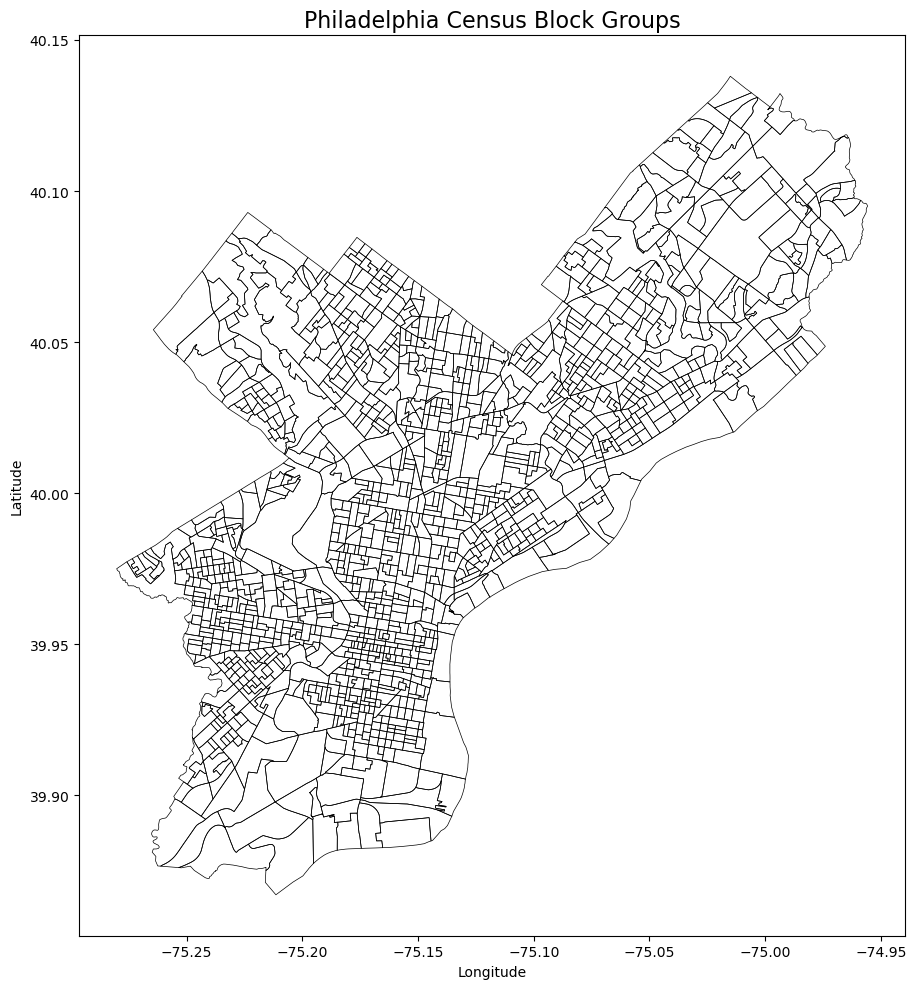

费城边界:
  经度: -75.2803° 到 -74.9558°
  纬度: 39.8670° 到 40.1380°


In [6]:
fig, ax = plt.subplots(figsize=(10, 10))
bg_philly.boundary.plot(ax=ax, linewidth=0.5, color='black')
ax.set_title('Philadelphia Census Block Groups', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

# 显示边界范围
bounds = bg_philly.total_bounds
print(f"费城边界:")
print(f"  经度: {bounds[0]:.4f}° 到 {bounds[2]:.4f}°")
print(f"  纬度: {bounds[1]:.4f}° 到 {bounds[3]:.4f}°")

## Step 7: 改进的数据提取函数

In [16]:
import tempfile
from rasterio.warp import calculate_default_transform, reproject
from rasterio.crs import CRS

def extract_and_georeference_viirs(hdf5_file):
    """
    提取VIIRS数据并转换为地理坐标
    """
    try:
        with rasterio.open(hdf5_file) as src:
            # 找夜间灯光子数据集
            ntl_subdataset = None
            for sd in src.subdatasets:
                if any(kw in sd for kw in ['Gap_Filled_DNB', 'NTL', 'DNB_BRDF', 'Radiance']):
                    ntl_subdataset = sd
                    break
            
            if ntl_subdataset is None and src.subdatasets:
                ntl_subdataset = src.subdatasets[0]
            
            if not ntl_subdataset:
                return None
            
            with rasterio.open(ntl_subdataset) as ntl_src:
                # 读取数据
                radiance = ntl_src.read(1)
                
                # 处理无效值
                nodata_val = ntl_src.nodata if ntl_src.nodata is not None else -999
                radiance = np.where(radiance == nodata_val, np.nan, radiance)
                radiance = np.where(radiance < 0, np.nan, radiance)
                
                # 获取或创建地理信息
                if ntl_src.crs and ntl_src.transform != Affine.identity():
                    # 如果有地理信息，直接使用
                    return radiance, ntl_src.transform, ntl_src.crs
                else:
                    # 从文件名推算tile位置
                    import re
                    filename = os.path.basename(hdf5_file)
                    match = re.search(r'h(\d{2})v(\d{2})', filename)
                    
                    if match:
                        h = int(match.group(1))
                        v = int(match.group(2))
                        
                        # VIIRS sinusoidal projection
                        # 每个tile约10度
                        tile_size = 10.0
                        left = -180 + h * tile_size
                        top = 90 - v * tile_size
                        
                        height, width = radiance.shape
                        pixel_size = tile_size / width
                        
                        transform = Affine(pixel_size, 0, left,
                                         0, -pixel_size, top)
                        crs = CRS.from_epsg(4326)
                        
                        return radiance, transform, crs
                    
    except Exception as e:
        print(f"    错误: {str(e)[:80]}")
    
    return None, None, None

print("✓ 改进的数据提取函数定义完成")

✓ 改进的数据提取函数定义完成


## Step 8: 测试读取一个文件

In [17]:
print(f"测试文件: {os.path.basename(test_file)}\\n")

radiance, transform, crs = extract_and_georeference_viirs(test_file)

if radiance is not None:
    print("✓ 成功读取数据")
    print(f"  数据形状: {radiance.shape}")
    print(f"  坐标系: {crs}")
    print(f"  Transform: {transform}")
    print(f"  亮度范围: {np.nanmin(radiance):.2f} - {np.nanmax(radiance):.2f}")
    print(f"  平均亮度: {np.nanmean(radiance):.2f}")
    
    # 检查transform是否有效
    bounds = rasterio.transform.array_bounds(radiance.shape[0], radiance.shape[1], transform)
    print(f"  数据边界: {bounds}")
else:
    print("✗ 读取失败")

测试文件: VNP46A2.A2023365.h29v05.002.2025142194003.h5\n
✓ 成功读取数据
  数据形状: (2400, 2400)
  坐标系: EPSG:4326
  Transform: | 0.00, 0.00, 110.00|
| 0.00,-0.00, 40.00|
| 0.00, 0.00, 1.00|
  亮度范围: 0.00 - 2410.09
  平均亮度: 2.48
  数据边界: (110.0, 30.0, 120.0, 40.0)


## Step 9: 计算Block Group的平均亮度（测试）

In [18]:
print("计算每个block group的平均亮度...\\n")

# 确保census数据和VIIRS数据在同一坐标系
if bg_philly.crs != crs:
    print(f"转换坐标系: {bg_philly.crs} → {crs}")
    bg_for_stats = bg_philly.to_crs(crs)
else:
    bg_for_stats = bg_philly

# 计算zonal statistics
try:
    stats = zonal_stats(
        bg_for_stats,
        radiance,
        affine=transform,
        stats=['mean', 'median', 'std', 'count'],
        nodata=np.nan,
        all_touched=True  # 添加这个参数
    )
    
    # 添加到dataframe
    bg_test = bg_philly.copy()
    bg_test['viirs_mean'] = [s['mean'] if s and s['mean'] is not None else np.nan for s in stats]
    bg_test['viirs_median'] = [s['median'] if s and s['median'] is not None else np.nan for s in stats]
    
    valid_count = bg_test['viirs_mean'].notna().sum()
    print(f"✓ 完成")
    print(f"  有数据的block groups: {valid_count} / {len(bg_test)} ({valid_count/len(bg_test)*100:.1f}%)")
    print(f"\\n亮度统计:")
    print(bg_test['viirs_mean'].describe())
    
except Exception as e:
    print(f"✗ 错误: {e}")
    print("\\n尝试备选方案...")

计算每个block group的平均亮度...\n
✓ 完成
  有数据的block groups: 0 / 1338 (0.0%)
\n亮度统计:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: viirs_mean, dtype: float64


In [19]:
# 检查哪些VIIRS文件覆盖费城
print("检查VIIRS文件覆盖区域...\\n")

# 费城边界
philly_bounds = bg_philly.total_bounds
print(f"费城位置: {philly_bounds}")
print(f"  经度: {philly_bounds[0]:.2f}° 到 {philly_bounds[2]:.2f}°")
print(f"  纬度: {philly_bounds[1]:.2f}° 到 {philly_bounds[3]:.2f}°")
print()

# 检查前10个文件的覆盖范围
philly_files = []

for i, vfile in enumerate(viirs_files[:20], 1):  # 先检查前20个
    radiance, transform, crs = extract_and_georeference_viirs(vfile)
    
    if radiance is not None and transform is not None:
        # 计算这个文件的边界
        bounds = rasterio.transform.array_bounds(
            radiance.shape[0], radiance.shape[1], transform
        )
        
        filename = os.path.basename(vfile)
        
        # 检查是否与费城重叠
        overlaps = not (bounds[2] < philly_bounds[0] or  # 文件在费城西边
                       bounds[0] > philly_bounds[2] or  # 文件在费城东边
                       bounds[3] < philly_bounds[1] or  # 文件在费城南边
                       bounds[1] > philly_bounds[3])    # 文件在费城北边
        
        status = "✓ 覆盖费城" if overlaps else "✗ 不覆盖"
        print(f"{i}. {filename[:40]}...")
        print(f"   边界: ({bounds[0]:.1f}, {bounds[1]:.1f}, {bounds[2]:.1f}, {bounds[3]:.1f})")
        print(f"   {status}")
        
        if overlaps:
            philly_files.append(vfile)

print(f"\\n{'='*70}")
print(f"找到 {len(philly_files)} 个覆盖费城的文件")

if len(philly_files) == 0:
    print("\\n⚠️ 警告：没有找到覆盖费城的VIIRS文件！")
    print("可能的原因：")
    print("1. 下载时搜索的地理范围设置错误")
    print("2. 需要重新下载正确tile的数据")

检查VIIRS文件覆盖区域...\n
费城位置: [-75.28026415  39.86700576 -74.95576188  40.13799261]
  经度: -75.28° 到 -74.96°
  纬度: 39.87° 到 40.14°

1. VNP46A2.A2023365.h29v05.002.202514219400...
   边界: (110.0, 30.0, 120.0, 40.0)
   ✗ 不覆盖
2. VNP46A2.A2023365.h29v06.002.202514317333...
   边界: (110.0, 20.0, 120.0, 30.0)
   ✗ 不覆盖
3. VNP46A2.A2023365.h30v06.002.202514219273...
   边界: (120.0, 20.0, 130.0, 30.0)
   ✗ 不覆盖
4. VNP46A3.A2021335.h10v04.001.202200811240...
   边界: (-80.0, 40.0, -70.0, 50.0)
   ✓ 覆盖费城
5. VNP46A3.A2021335.h10v05.001.202200810570...
   边界: (-80.0, 30.0, -70.0, 40.0)
   ✓ 覆盖费城
6. VNP46A3.A2022001.h10v04.001.202207620495...
   边界: (-80.0, 40.0, -70.0, 50.0)
   ✓ 覆盖费城
7. VNP46A3.A2022001.h10v05.001.202207620495...
   边界: (-80.0, 30.0, -70.0, 40.0)
   ✓ 覆盖费城
8. VNP46A3.A2022032.h10v04.001.202207004322...
   边界: (-80.0, 40.0, -70.0, 50.0)
   ✓ 覆盖费城
9. VNP46A3.A2022032.h10v05.001.202207004322...
   边界: (-80.0, 30.0, -70.0, 40.0)
   ✓ 覆盖费城
10. VNP46A3.A2022060.h10v04.001.202209811295...
   边界: (-8

## Step 10: 可视化测试结果

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

bg_test.plot(
    column='viirs_mean',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.2,
    legend_kwds={'label': 'Nighttime Radiance (nW/cm²/sr)', 'shrink': 0.7}
)

ax.set_title('Philadelphia Nighttime Light Intensity\n(Test - Single Month)', fontsize=16, pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✓ 测试成功！")
print("可以看到费城不同区域的亮度差异")
print("Downtown和富人区明显更亮")

## Step 11: 处理所有VIIRS文件

⚠️ **注意：这一步会需要一些时间（约10-20分钟），因为要处理77个文件**

In [21]:
# 初始化结果dataframe
bg_result = bg_philly.copy()

# 只处理覆盖费城的tile (h10v04 和 h10v05)
philly_viirs_files = [f for f in viirs_files if 'h10v' in os.path.basename(f)]

print(f"开始处理费城区域的VIIRS文件")
print(f"总共 {len(viirs_files)} 个文件，其中 {len(philly_viirs_files)} 个覆盖费城")
print("="*70)

# 记录处理时间
import time
start_time = time.time()

# 处理每个文件
success_count = 0
fail_count = 0

for i, viirs_file in enumerate(philly_viirs_files, 1):
    filename = os.path.basename(viirs_file)
    
    # 提取日期信息
    try:
        # VNP46A3.A2024001.h10v05.001.hdf5
        parts = filename.split('.')
        date_str = parts[1]  # A2024001
        year = date_str[1:5]
        doy = date_str[5:8]
        date = datetime.strptime(f"{year}-{doy}", "%Y-%j")
        date_key = date.strftime("%Y-%m")
        tile = parts[2]  # h10v05
    except:
        date_key = f"file_{i}"
        tile = "unknown"
    
    # 显示进度
    print(f"[{i}/{len(philly_viirs_files)}] {date_key} ({tile}): {filename[:45]}...")
    
    # 提取数据
    radiance, transform, crs = extract_and_georeference_viirs(viirs_file)
    
    if radiance is None or transform is None:
        print(f"    ✗ 跳过（读取失败）")
        fail_count += 1
        continue
    
    # 确保坐标系一致
    if bg_philly.crs != crs:
        bg_for_stats = bg_philly.to_crs(crs)
    else:
        bg_for_stats = bg_philly
    
    # 计算zonal stats
    try:
        stats = zonal_stats(
            bg_for_stats,
            radiance,
            affine=transform,
            stats=['mean'],
            nodata=np.nan,
            all_touched=True
        )
        
        # 如果这个日期已经有数据，取最大值（因为有两个tile：h10v04和h10v05）
        col_name = f'viirs_{date_key}'
        
        if col_name in bg_result.columns:
            # 已经有这个月的数据，合并（取最大值）
            new_values = [s['mean'] if s and s['mean'] is not None else np.nan for s in stats]
            bg_result[col_name] = np.nanmax([bg_result[col_name], new_values], axis=0)
        else:
            # 新数据
            bg_result[col_name] = [s['mean'] if s and s['mean'] is not None else np.nan for s in stats]
        
        valid_count = pd.notna(bg_result[col_name]).sum()
        print(f"    ✓ 完成 ({valid_count}/{len(bg_result)} 有数据)")
        success_count += 1
        
    except Exception as e:
        print(f"    ✗ 处理失败: {str(e)[:50]}")
        fail_count += 1

# 计算耗时
elapsed_time = time.time() - start_time
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print("\n" + "="*70)
print("处理完成！")
print("="*70)
print(f"成功: {success_count} 个文件")
print(f"失败: {fail_count} 个文件")
print(f"耗时: {minutes}分{seconds}秒")

开始处理费城区域的VIIRS文件
总共 77 个文件，其中 74 个覆盖费城
[1/74] 2021-12 (h10v04): VNP46A3.A2021335.h10v04.001.2022008112402.h5...
    ✓ 完成 (640/1338 有数据)
[2/74] 2021-12 (h10v05): VNP46A3.A2021335.h10v05.001.2022008105704.h5...
    ✓ 完成 (1338/1338 有数据)
[3/74] 2022-01 (h10v04): VNP46A3.A2022001.h10v04.001.2022076204957.h5...
    ✓ 完成 (640/1338 有数据)
[4/74] 2022-01 (h10v05): VNP46A3.A2022001.h10v05.001.2022076204956.h5...
    ✓ 完成 (1338/1338 有数据)
[5/74] 2022-02 (h10v04): VNP46A3.A2022032.h10v04.001.2022070043222.h5...
    ✓ 完成 (640/1338 有数据)
[6/74] 2022-02 (h10v05): VNP46A3.A2022032.h10v05.001.2022070043225.h5...
    ✓ 完成 (1338/1338 有数据)
[7/74] 2022-03 (h10v04): VNP46A3.A2022060.h10v04.001.2022098112953.h5...
    ✓ 完成 (640/1338 有数据)
[8/74] 2022-03 (h10v05): VNP46A3.A2022060.h10v05.001.2022098111029.h5...
    ✓ 完成 (1338/1338 有数据)
[9/74] 2022-04 (h10v04): VNP46A3.A2022091.h10v04.001.2022128104934.h5...
    ✓ 完成 (640/1338 有数据)
[10/74] 2022-04 (h10v05): VNP46A3.A2022091.h10v05.001.2022128100947.h5...
    ✓ 完成 (

## Step 12: 计算年度和趋势指标

In [22]:
print("计算年度和趋势指标...\n")

# 找到所有VIIRS列
viirs_cols = [col for col in bg_result.columns if col.startswith('viirs_') and col.count('-') == 1]

print(f"共有 {len(viirs_cols)} 个月的数据")

# 按年份分组
viirs_2024_cols = [col for col in viirs_cols if '2024' in col]
viirs_2023_cols = [col for col in viirs_cols if '2023' in col]
viirs_2022_cols = [col for col in viirs_cols if '2022' in col]

print(f"  2024年: {len(viirs_2024_cols)} 个月")
print(f"  2023年: {len(viirs_2023_cols)} 个月")
print(f"  2022年: {len(viirs_2022_cols)} 个月")

# 计算年度平均值
if viirs_2024_cols:
    bg_result['viirs_2024_mean'] = bg_result[viirs_2024_cols].mean(axis=1)
    print(f"\n✓ 计算2024年平均值")

if viirs_2023_cols:
    bg_result['viirs_2023_mean'] = bg_result[viirs_2023_cols].mean(axis=1)
    print(f"✓ 计算2023年平均值")

if viirs_2022_cols:
    bg_result['viirs_2022_mean'] = bg_result[viirs_2022_cols].mean(axis=1)
    print(f"✓ 计算2022年平均值")

# 计算整体平均值（2022-2024）
if viirs_cols:
    bg_result['viirs_all_mean'] = bg_result[viirs_cols].mean(axis=1)
    print(f"✓ 计算2022-2024整体平均值")

# 计算2022-2024变化
if 'viirs_2024_mean' in bg_result.columns and 'viirs_2022_mean' in bg_result.columns:
    bg_result['viirs_change_2022_2024'] = bg_result['viirs_2024_mean'] - bg_result['viirs_2022_mean']
    bg_result['viirs_pct_change_2022_2024'] = (
        (bg_result['viirs_2024_mean'] - bg_result['viirs_2022_mean']) / 
        (bg_result['viirs_2022_mean'] + 0.001) * 100  # 加0.001避免除零
    )
    print(f"✓ 计算2022-2024变化率")

print("\n最终数据摘要:")
summary_cols = [col for col in bg_result.columns if 'viirs' in col and 'mean' in col]
print(bg_result[summary_cols].describe())

计算年度和趋势指标...

共有 37 个月的数据
  2024年: 12 个月
  2023年: 12 个月
  2022年: 12 个月

✓ 计算2024年平均值
✓ 计算2023年平均值
✓ 计算2022年平均值
✓ 计算2022-2024整体平均值
✓ 计算2022-2024变化率

最终数据摘要:
       viirs_2024_mean  viirs_2023_mean  viirs_2022_mean  viirs_all_mean
count      1338.000000      1338.000000      1338.000000     1338.000000
mean        893.369191       815.982758       837.977691      847.110442
std         490.297469       516.082619       523.156572      507.777354
min         155.356481       144.243056       141.013889      149.862613
25%         615.828125       532.445238       553.913194      565.186486
50%         785.895833       686.202778       711.996528      730.640541
75%         981.430556       903.078125       921.915509      936.655405
max        3977.138889      4114.861111      4556.194444     4220.756757


## Step 13: 可视化最终结果

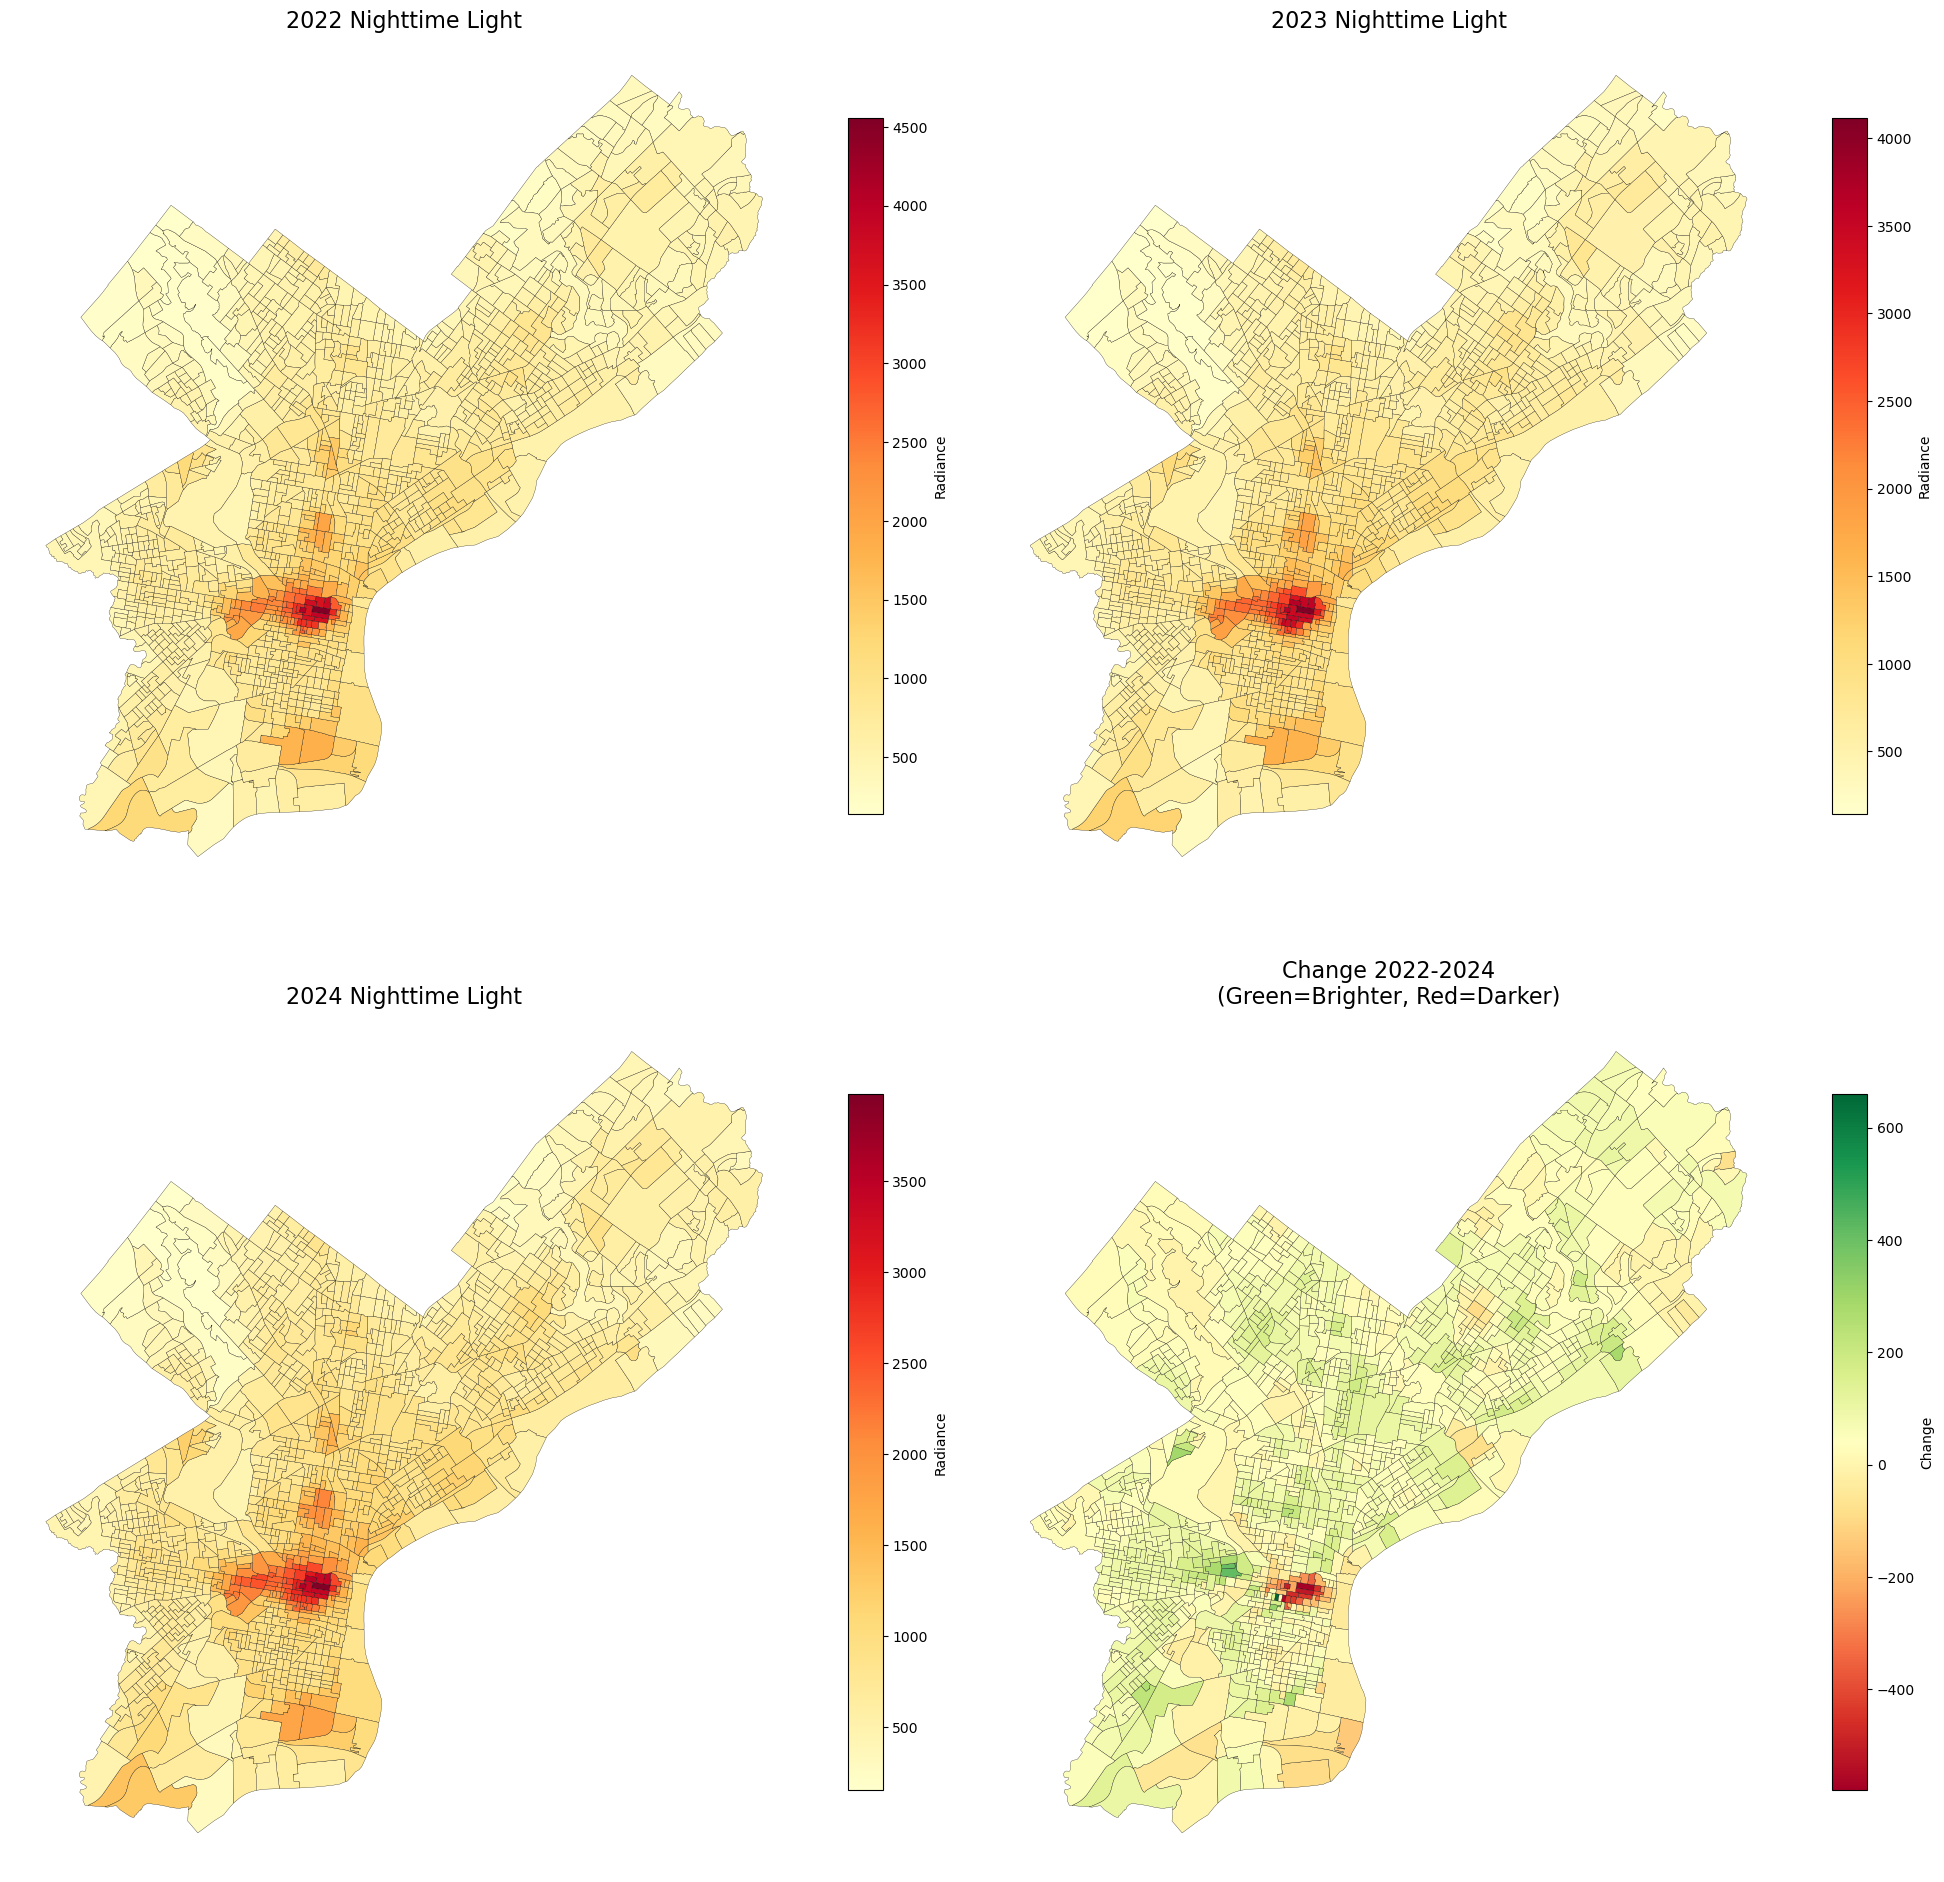

✓ 地图已保存到输出目录


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# 2022
if 'viirs_2022_mean' in bg_result.columns:
    bg_result.plot(column='viirs_2022_mean', ax=axes[0, 0], legend=True, 
                   cmap='YlOrRd', edgecolor='black', linewidth=0.2,
                   legend_kwds={'label': 'Radiance', 'shrink': 0.7})
    axes[0, 0].set_title('2022 Nighttime Light', fontsize=16)
    axes[0, 0].axis('off')

# 2023
if 'viirs_2023_mean' in bg_result.columns:
    bg_result.plot(column='viirs_2023_mean', ax=axes[0, 1], legend=True,
                   cmap='YlOrRd', edgecolor='black', linewidth=0.2,
                   legend_kwds={'label': 'Radiance', 'shrink': 0.7})
    axes[0, 1].set_title('2023 Nighttime Light', fontsize=16)
    axes[0, 1].axis('off')

# 2024
if 'viirs_2024_mean' in bg_result.columns:
    bg_result.plot(column='viirs_2024_mean', ax=axes[1, 0], legend=True,
                   cmap='YlOrRd', edgecolor='black', linewidth=0.2,
                   legend_kwds={'label': 'Radiance', 'shrink': 0.7})
    axes[1, 0].set_title('2024 Nighttime Light', fontsize=16)
    axes[1, 0].axis('off')

# Change
if 'viirs_change_2022_2024' in bg_result.columns:
    bg_result.plot(column='viirs_change_2022_2024', ax=axes[1, 1], legend=True,
                   cmap='RdYlGn', edgecolor='black', linewidth=0.2,
                   legend_kwds={'label': 'Change', 'shrink': 0.7})
    axes[1, 1].set_title('Change 2022-2024\n(Green=Brighter, Red=Darker)', fontsize=16)
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viirs_summary_maps.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ 地图已保存到输出目录")

## Step 14: 导出结果

In [24]:
print("导出数据...\n")

# 1. Shapefile（用于ArcGIS）
shp_path = os.path.join(OUTPUT_DIR, "philly_lighting_data.shp")
bg_result.to_file(shp_path)
print(f"✓ Shapefile: {shp_path}")

# 2. GeoJSON（用于web mapping）
geojson_path = os.path.join(OUTPUT_DIR, "philly_lighting_data.geojson")
bg_result.to_file(geojson_path, driver='GeoJSON')
print(f"✓ GeoJSON: {geojson_path}")

# 3. CSV（用于快速分析）
csv_data = bg_result.copy()
csv_data['geometry'] = csv_data['geometry'].apply(lambda x: x.wkt)
csv_path = os.path.join(OUTPUT_DIR, "philly_lighting_data.csv")
csv_data.to_csv(csv_path, index=False)
print(f"✓ CSV: {csv_path}")

# 4. 摘要统计
summary_path = os.path.join(OUTPUT_DIR, "viirs_summary.txt")
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write("VIIRS NIGHTTIME LIGHTS - PHILADELPHIA\n")
    f.write("="*70 + "\n\n")
    f.write(f"处理日期: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write(f"Block groups总数: {len(bg_result)}\n")
    f.write(f"时间跨度: 2022-2024\n")
    f.write(f"\n数据文件: {success_count} 个\n\n")
    
    if 'viirs_2024_mean' in bg_result.columns:
        f.write("2024年亮度统计:\n")
        f.write(bg_result['viirs_2024_mean'].describe().to_string())
        f.write("\n\n")
    
    if 'viirs_change_2022_2024' in bg_result.columns:
        f.write("2022-2024变化统计:\n")
        f.write(bg_result['viirs_change_2022_2024'].describe().to_string())

print(f"✓ 摘要: {summary_path}")

print("\n" + "="*70)
print("所有数据导出完成！")
print("="*70)
print(f"\n输出目录: {OUTPUT_DIR}")
print(f"\n包含:")
print(f"  • {len(bg_result)} 个census block groups")
print(f"  • {len(viirs_cols)} 个月的VIIRS数据")
print(f"  • 2022-2024 三年趋势")

导出数据...

✓ Shapefile: D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\processed_data\philly_lighting_data.shp
✓ GeoJSON: D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\processed_data\philly_lighting_data.geojson
✓ CSV: D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\processed_data\philly_lighting_data.csv
✓ 摘要: D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\processed_data\viirs_summary.txt

所有数据导出完成！

输出目录: D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\processed_data

包含:
  • 1338 个census block groups
  • 37 个月的VIIRS数据
  • 2022-2024 三年趋势


In [1]:
import os
import glob

# 找到要删除的文件
viirs_dir = r"D:\pen\MUSA5500GeospatialDataScienceInPython\final\finaldata\viirs_data"
all_files = glob.glob(os.path.join(viirs_dir, "*.h5"))

files_to_delete = []
for f in all_files:
    filename = os.path.basename(f)
    # 中国区域 或 2021年数据
    if any(x in filename for x in ['h29v', 'h30v', 'A2021']):
        files_to_delete.append(f)

print(f"将删除 {len(files_to_delete)} 个文件:\n")
for f in files_to_delete:
    size_mb = os.path.getsize(f) / (1024*1024)
    print(f"  {os.path.basename(f)} ({size_mb:.1f} MB)")

# 确认后删除
confirm = input("\n确认删除? (yes/no): ")
if confirm.lower() == 'yes':
    for f in files_to_delete:
        os.remove(f)
        print(f"✓ 已删除: {os.path.basename(f)}")
    print(f"\n共删除 {len(files_to_delete)} 个文件")
else:
    print("已取消")

将删除 5 个文件:

  VNP46A2.A2023365.h29v05.002.2025142194003.h5 (35.1 MB)
  VNP46A2.A2023365.h29v06.002.2025143173338.h5 (24.7 MB)
  VNP46A2.A2023365.h30v06.002.2025142192736.h5 (19.1 MB)
  VNP46A3.A2021335.h10v04.001.2022008112402.h5 (31.1 MB)
  VNP46A3.A2021335.h10v05.001.2022008105704.h5 (10.0 MB)



确认删除? (yes/no):  yes


✓ 已删除: VNP46A2.A2023365.h29v05.002.2025142194003.h5
✓ 已删除: VNP46A2.A2023365.h29v06.002.2025143173338.h5
✓ 已删除: VNP46A2.A2023365.h30v06.002.2025142192736.h5
✓ 已删除: VNP46A3.A2021335.h10v04.001.2022008112402.h5
✓ 已删除: VNP46A3.A2021335.h10v05.001.2022008105704.h5

共删除 5 个文件


## ✅ 完成！

### 🎉 你现在有了：

**1. 数据文件：**
- ✅ `philly_lighting_data.shp` - 可以直接上传到ArcGIS
- ✅ `philly_lighting_data.geojson` - 可以用于web地图
- ✅ `philly_lighting_data.csv` - 可以在Excel或Python中分析
- ✅ `viirs_summary_maps.png` - 可视化图表
- ✅ `viirs_summary.txt` - 统计摘要

**2. 数据内容：**
- Census block group地理信息
- 2022-2024每个月的VIIRS亮度
- 年度平均值（2022, 2023, 2024）
- 整体平均值（2022-2024）
- 变化量和变化率

**3. 关键字段：**
- `GEOID` - Block group唯一标识
- `viirs_2024_mean` - 2024年平均亮度
- `viirs_2023_mean` - 2023年平均亮度
- `viirs_2022_mean` - 2022年平均亮度
- `viirs_change_2022_2024` - 变化量
- `viirs_pct_change_2022_2024` - 变化百分比

---

### 📊 下一步：

1. **合并其他数据**
   - 311维修数据 (311_service文件夹)
   - 犯罪数据 (crime文件夹)
   - 人口统计数据 (acs文件夹)

2. **开始分析**
   - Complaint Gap分析
   - 照明与犯罪相关性
   - 维修公平性分析

3. **制作地图**
   - 上传到ArcGIS Online
   - 制作StoryMap

---

**有任何问题随时问我！** 👍